In [1]:
import h5py
import numpy as np
import scanpy as sc
from anndata import AnnData
from scipy import sparse
import pandas as pd
import sys
sys.path.append(r"D:\Scunpair_Project\Diagonal-integration")
import mycode

def data_loader(path):
    with h5py.File(path, "r") as f:
        X = np.array(f['matrix/data']).transpose()
        var_names = np.array(f['matrix/features']).astype(str)
        obs_names = np.array(f['matrix/barcodes']).astype(str)
    adata = AnnData(X=sparse.csr_matrix(X))
    adata.obs_names = obs_names
    adata.var_names = var_names
    return adata

In [2]:
file_path = "D:/Scunpair_Project/Dataset/datasets/datasets/D37/"
rna = data_loader(file_path+"rna1.h5")
rna_cty = pd.read_csv(file_path+"rna_cty1.csv")
rna.obs['cell_type'] = rna_cty['x'].values

atac_peak = data_loader(file_path+"atac_peak1.h5")
atac_cty = pd.read_csv(file_path+"atac_cty1.csv")
atac_peak.obs['cell_type'] = atac_cty['x'].values

atac_gas = data_loader(file_path+"atac_gas1.h5")
atac_gas.obs['cell_type'] = atac_cty['x'].values

In [6]:
sc.pp.highly_variable_genes(rna, flavor='seurat_v3', n_top_genes=2000, subset=True)
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna)
sc.pp.pca(rna)
sc.pp.neighbors(rna)
sc.tl.umap(rna)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


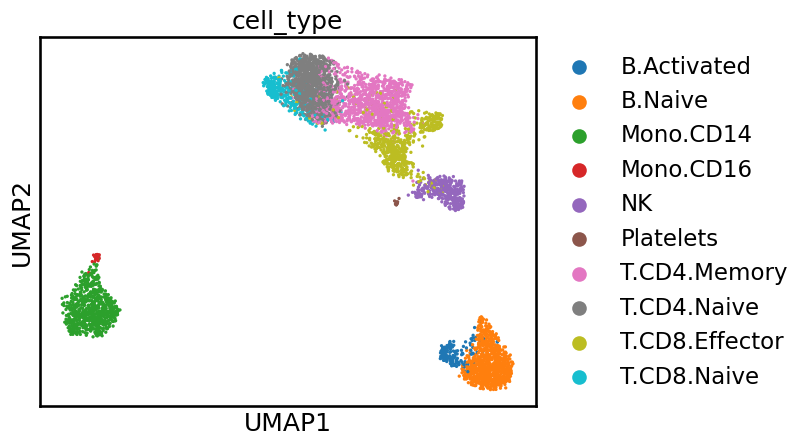

In [7]:
sc.pl.umap(rna, color=['cell_type'])

In [8]:
mycode.utils.lsi(atac_peak, n_components=100)
sc.pp.neighbors(atac_peak, use_rep='X_lsi')
sc.tl.umap(atac_peak)

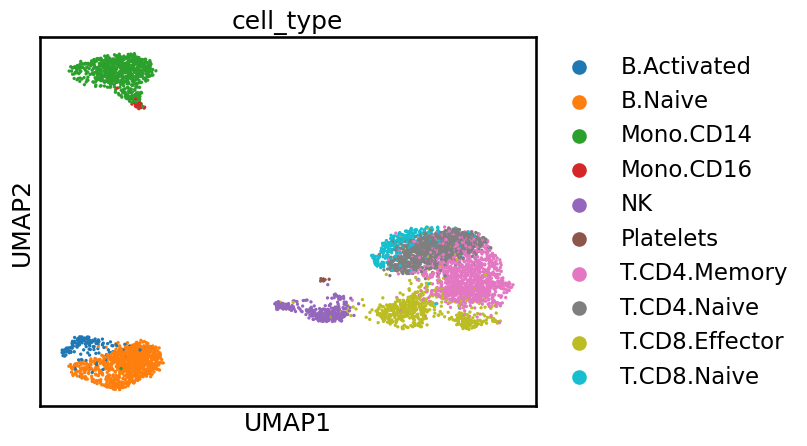

In [9]:
sc.pl.umap(atac_peak, color=['cell_type'])

In [ ]:
sc.pp.normalize_total(adt)
sc.pp.log1p(adt)
# mycode.utils.clr(adt)
sc.pp.scale(adt,max_value=10)
sc.pp.pca(adt)
sc.pp.neighbors(adt)
sc.tl.umap(adt)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


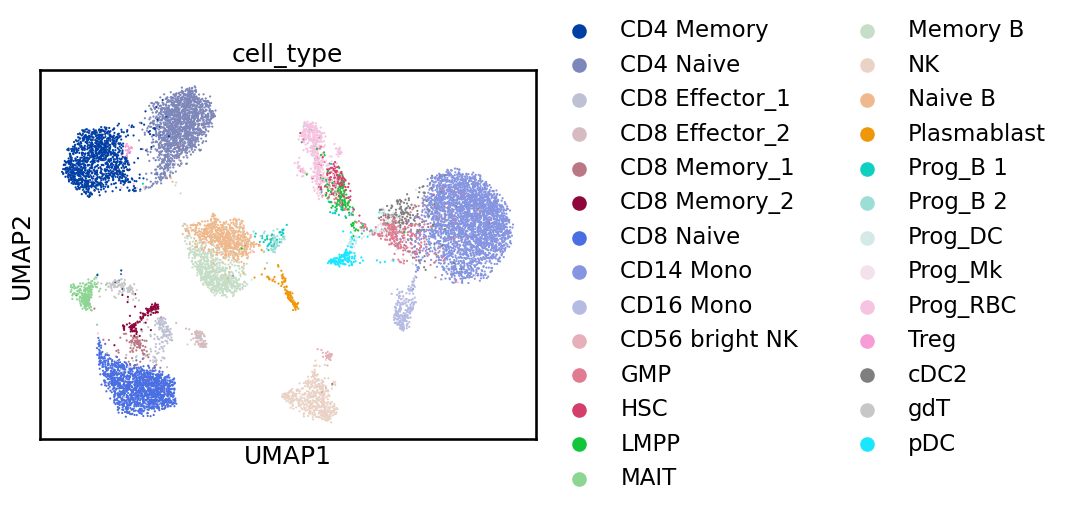

In [9]:
sc.pl.umap(adt, color=['cell_type'])